In [1]:
import sys
sys.path.append("..")

import pandas as pd
import time
from config.settings import *
from config.feature_registry import OPEN_METEO_HOURLY_PARAMS, NASA_POWER_PARAMS
from src.data_collection.open_meteo_client import OpenMeteoClient
from src.data_collection.nasa_power_client import NASAPowerClient
from src.data_collection.data_validator import DataValidator
from src.utils.io_helpers import save_parquet, load_parquet

# Load grid points
land_df = pd.read_csv(INTERIM_DIR / "grid_points_india.csv")
print(f"📍 Total grid points: {len(land_df)}")
print(f"📅 Date range: {START_DATE} → {END_DATE}")
print(f"🌤️  Open-Meteo params: {len(OPEN_METEO_HOURLY_PARAMS)}")
print(f"🛰️  NASA POWER params: {len(NASA_POWER_PARAMS)}")
land_df.head()

2026-05-04 11:09:18 | INFO     | io | 📁 Storage format: parquet (parquet available: True)


📍 Total grid points: 1153
📅 Date range: 2000-01-01 → 2024-12-31
🌤️  Open-Meteo params: 22
🛰️  NASA POWER params: 15


,point_id,latitude,longitude
0,PT_00000,8.5,77.0
1,PT_00001,8.5,77.5
2,PT_00002,8.5,78.0
3,PT_00003,9.0,77.0
4,PT_00004,9.0,77.5


In [2]:
# Clean old files
for f in (RAW_DIR / "open_meteo").glob("*"):
    f.unlink()

# Test parallel with 3 points
test_df = land_df.head(3)

test_client = OpenMeteoClient(
    start_date="2024-01-01",
    end_date="2024-01-31",
    max_workers=3,  # 3 workers for 3 points
)

test_client.fetch_all(test_df, resume=False)

2026-05-04 11:09:20 | INFO     | open_meteo | 🌤️  OpenMeteoClient initialized (HOURLY + PARALLEL) | Period: 2024-01-01 → 2024-01-31 | Parameters: 22 | Chunks: 1 | Workers: 3
2026-05-04 11:09:20 | INFO     | open_meteo | ⏱️  Estimated time: 0.0 hours | Points: 3 | Workers: 3
2026-05-04 11:09:20 | INFO     | timer | ⏱️  Started: Fetching 3 points (parallel × 3)
🌤️  Open-Meteo (parallel): 100%|██████████| 3/3 [00:02<00:00,  1.27points/s, success=3, failed=0]
2026-05-04 11:09:22 | INFO     | timer | ✅ Finished: Fetching 3 points (parallel × 3) [2.40s]
2026-05-04 11:09:22 | INFO     | open_meteo | 📊 Collection complete | Success: 3 | Failed: 0


In [3]:
# Check saved files
saved_files = list((RAW_DIR / "open_meteo").glob("*.csv"))
print(f"📁 Files saved: {len(saved_files)}")
for f in saved_files:
    size_kb = f.stat().st_size / 1024
    print(f"   {f.name} ({size_kb:.1f} KB)")

# Load and inspect one file
sample = pd.read_csv(saved_files[0])
print(f"\n📊 Shape: {sample.shape}")
print(f"📅 Date range: {sample['date'].min()} → {sample['date'].max()}")
print(f"📋 Columns ({len(sample.columns)}):\n")

for col in sample.columns:
    non_null = sample[col].notna().sum()
    pct = non_null / len(sample) * 100
    status = "✅" if pct > 90 else "⚠️" if pct > 50 else "❌"
    print(f"   {status} {col:<40s} {pct:5.1f}% | sample: {sample[col].iloc[0]}")

📁 Files saved: 3
   open_meteo_PT_00000_8.5_77.0.csv (14.2 KB)
   open_meteo_PT_00001_8.5_77.5.csv (14.1 KB)
   open_meteo_PT_00002_8.5_78.0.csv (14.2 KB)

📊 Shape: (31, 55)
📅 Date range: 2024-01-01 → 2024-01-31
📋 Columns (55):

   ✅ date                                     100.0% | sample: 2024-01-01
   ✅ temperature_2m_mean                      100.0% | sample: 28.133333333333336
   ✅ temperature_2m_max                       100.0% | sample: 30.4
   ✅ temperature_2m_min                       100.0% | sample: 26.7
   ✅ temperature_2m_std                       100.0% | sample: 1.2056629663408411
   ✅ apparent_temperature_mean                100.0% | sample: 32.766666666666666
   ✅ apparent_temperature_max                 100.0% | sample: 35.8
   ✅ apparent_temperature_min                 100.0% | sample: 30.3
   ✅ dewpoint_2m_mean                         100.0% | sample: 23.454166666666666
   ✅ dewpoint_2m_min                          100.0% | sample: 22.6
   ✅ relative_humidity_2m_mea

In [4]:
test_combined = test_client.combine_all()

print(f"📊 Combined shape: {test_combined.shape}")
print(f"📍 Unique points: {test_combined[['latitude','longitude']].drop_duplicates().shape[0]}")

# Show a nice preview
core_cols = [c for c in test_combined.columns if any(
    c.startswith(p) for p in ["date", "lat", "lon", "temperature_2m", "precipitation", "wind_speed_10m", "cloud_cover_mean", "frost", "hot", "comfortable"]
)]
test_combined[core_cols].head(10)

2026-05-04 11:09:31 | INFO     | open_meteo | 📦 Combining 3 point files...
Combining: 100%|██████████| 3/3 [00:00<00:00, 50.68files/s]
2026-05-04 11:09:31 | INFO     | open_meteo | ✅ Combined dataset: 93 rows | 1 unique points | Columns: 55 | Date range: 2024-01-01 00:00:00 → 2024-01-31 00:00:00


📊 Combined shape: (93, 55)
📍 Unique points: 3


,date,temperature_2m_mean,temperature_2m_max,temperature_2m_min,temperature_2m_std,precipitation_sum,precipitation_max,cloud_cover_mean,wind_speed_10m_mean,wind_speed_10m_max,wind_speed_10m_std,frost_hours,hot_hours,comfortable_hours,precipitation_hours,latitude,longitude
0,2024-01-01,28.133333,30.4,26.7,1.205663,0.1,0.1,97.958333,7.804167,11.7,2.281014,0,0,14,1,8.5,77.0
1,2024-01-02,28.700000,32.0,26.3,1.845087,0.1,0.1,35.083333,6.341667,11.3,3.146553,0,0,11,1,8.5,77.0
2,2024-01-03,28.595833,31.8,26.7,1.811672,1.3,0.5,34.125000,6.941667,11.4,3.303347,0,0,13,5,8.5,77.0
3,2024-01-04,28.858333,31.9,26.4,1.975924,0.3,0.2,96.583333,6.491667,11.0,2.923654,0,0,11,2,8.5,77.0
4,2024-01-05,28.458333,31.6,26.5,1.584412,4.7,3.0,81.750000,4.870833,11.2,2.546179,0,0,11,9,8.5,77.0
5,2024-01-06,28.300000,30.6,26.9,1.159085,19.0,10.1,77.000000,4.387500,8.8,2.025127,0,0,13,16,8.5,77.0
6,2024-01-07,27.854167,30.8,26.1,1.451829,8.7,3.1,90.791667,4.429167,7.9,1.889670,0,0,16,15,8.5,77.0
7,2024-01-08,28.216667,31.0,26.5,1.445433,1.3,0.4,99.458333,5.829167,9.0,1.786295,0,0,13,7,8.5,77.0
8,2024-01-09,27.329167,28.8,25.6,0.897571,6.7,1.5,99.750000,5.875000,7.5,0.920893,0,0,18,17,8.5,77.0
9,2024-01-10,27.720833,30.5,25.7,1.805783,2.7,0.5,97.791667,5.712500,9.5,2.070142,0,0,15,9,8.5,77.0


In [5]:
# Based on test: 3 points took 25.41 seconds with 1 chunk
# Full run: 1153 points × 5 chunks

seconds_per_point_per_chunk = 25.41 / 3  # ~8.47s per point for 1 chunk
full_chunks = 5  # 25 years / 5 years per chunk

# But each chunk is a separate API call, so time per point scales with chunks
# Test had 1 chunk per point (1 month range)
# Full run has 5 chunks per point (25 years)
seconds_per_point_full = seconds_per_point_per_chunk * full_chunks
total_seconds = len(land_df) * seconds_per_point_full
total_hours = total_seconds / 3600

print("=" * 60)
print("  ⏱️  FULL COLLECTION TIME ESTIMATE")
print("=" * 60)
print(f"  Points:              {len(land_df)}")
print(f"  Chunks per point:    {full_chunks}")
print(f"  Sec/point (1 chunk): ~{seconds_per_point_per_chunk:.1f}s")
print(f"  Sec/point (full):    ~{seconds_per_point_full:.1f}s")
print(f"  Total estimated:     ~{total_hours:.1f} hours")
print(f"")
print(f"  💡 TIP: Resume is enabled!")
print(f"     If it stops/crashes, just re-run — it picks up where it left off")
print("=" * 60)

  ⏱️  FULL COLLECTION TIME ESTIMATE
  Points:              1153
  Chunks per point:    5
  Sec/point (1 chunk): ~8.5s
  Sec/point (full):    ~42.4s
  Total estimated:     ~13.6 hours

  💡 TIP: Resume is enabled!
     If it stops/crashes, just re-run — it picks up where it left off


In [ ]:
# ══════════════════════════════════════════════════════════════
#  STEP 5: FULL OPEN-METEO COLLECTION
#  ⚠️  THIS TAKES TIME — Only run when test is verified!
# ══════════════════════════════════════════════════════════════

# Clear test data first
import shutil
test_files = list((RAW_DIR / "open_meteo").glob("*.parquet"))
if test_files:
    print(f"🗑️  Removing {len(test_files)} test files...")
    for f in test_files:
        f.unlink()

# Time estimate
full_client = OpenMeteoClient()  # Uses full date range from settings

chunks = len(full_client.date_chunks)
total_api_calls = len(land_df) * chunks
est_minutes = total_api_calls / (5 * 60)  # 5 requests/sec

print("=" * 60)
print("  📋 FULL COLLECTION PLAN")
print("=" * 60)
print(f"  📍 Points:        {len(land_df)}")
print(f"  📅 Date range:    {START_DATE} → {END_DATE}")
print(f"  📦 Chunks/point:  {chunks}")
print(f"  🌐 API calls:     {total_api_calls:,}")
print(f"  ⏱️  Est. time:     ~{est_minutes:.0f} minutes ({est_minutes/60:.1f} hours)")
print(f"  💡 Resume enabled: Will skip already downloaded points")
print("=" * 60)

proceed = input("\n🚀 Start collection? (yes/no): ")
if proceed.lower() == "yes":
    full_client.fetch_all(land_df, resume=True)
    print("\n✅ Open-Meteo collection complete!")
else:
    print("⏸️  Collection skipped.")

2026-05-04 11:09:37 | INFO     | open_meteo | 🌤️  OpenMeteoClient initialized (HOURLY + PARALLEL) | Period: 2000-01-01 → 2024-12-31 | Parameters: 22 | Chunks: 5 | Workers: 5


  📋 FULL COLLECTION PLAN
  📍 Points:        1153
  📅 Date range:    2000-01-01 → 2024-12-31
  📦 Chunks/point:  5
  🌐 API calls:     5,765
  ⏱️  Est. time:     ~19 minutes (0.3 hours)
  💡 Resume enabled: Will skip already downloaded points


In [7]:
# ══════════════════════════════════════════════════════════════
#  STEP 6: FULL NASA POWER COLLECTION
# ══════════════════════════════════════════════════════════════

# Clear test NASA data
test_nasa_files = list((RAW_DIR / "nasa_power").glob("*.parquet"))
if test_nasa_files:
    print(f"🗑️  Removing {len(test_nasa_files)} test files...")
    for f in test_nasa_files:
        f.unlink()

nasa_client = NASAPowerClient()

est_minutes_nasa = len(land_df) / (2 * 60)  # 2 requests/sec

print("=" * 60)
print("  📋 NASA POWER COLLECTION PLAN")
print("=" * 60)
print(f"  📍 Points:        {len(land_df)}")
print(f"  📅 Date range:    {START_DATE} → {END_DATE}")
print(f"  🌐 API calls:     {len(land_df)}")
print(f"  ⏱️  Est. time:     ~{est_minutes_nasa:.0f} minutes")
print("=" * 60)

proceed = input("\n🚀 Start NASA collection? (yes/no): ")
if proceed.lower() == "yes":
    nasa_client.fetch_all(land_df, resume=True)
    print("\n✅ NASA POWER collection complete!")
else:
    print("⏸️  Collection skipped.")

2026-05-01 10:39:56 | INFO     | nasa_power | 🛰️  NASAPowerClient initialized | Period: 2000-01-01 → 2024-12-31 | Parameters: 15


  📋 NASA POWER COLLECTION PLAN
  📍 Points:        1153
  📅 Date range:    2000-01-01 → 2024-12-31
  🌐 API calls:     1153
  ⏱️  Est. time:     ~10 minutes
⏸️  Collection skipped.


In [12]:
# ══════════════════════════════════════════════════════════════
#  STEP 7: COMBINE AND SAVE
# ══════════════════════════════════════════════════════════════

print("📦 Combining Open-Meteo data...")
om_client = OpenMeteoClient()
om_combined = om_client.combine_all()

print(f"\n📊 Open-Meteo Combined:")
print(f"   Rows: {len(om_combined):,}")
print(f"   Columns: {len(om_combined.columns)}")
print(f"   Points: {om_combined[['latitude','longitude']].drop_duplicates().shape[0]}")
print(f"   Date range: {om_combined['date'].min()} → {om_combined['date'].max()}")

# Save
save_parquet(
    om_combined,
    INTERIM_DIR / "open_meteo_combined.parquet",
    description="Open-Meteo aggregated daily data"
)

print("\n" + "=" * 50)

print("\n📦 Combining NASA POWER data...")
nasa_client_combine = NASAPowerClient()
nasa_combined = nasa_client_combine.combine_all()

print(f"\n📊 NASA POWER Combined:")
print(f"   Rows: {len(nasa_combined):,}")
print(f"   Columns: {len(nasa_combined.columns)}")
print(f"   Points: {nasa_combined[['latitude','longitude']].drop_duplicates().shape[0]}")

save_parquet(
    nasa_combined,
    INTERIM_DIR / "nasa_power_combined.parquet",
    description="NASA POWER daily data"
)

2026-05-01 10:41:15 | INFO     | open_meteo | 🌤️  OpenMeteoClient initialized (HOURLY mode) | Period: 2000-01-01 → 2024-12-31 | Parameters: 22 | Chunks: 5
2026-05-01 10:41:15 | INFO     | open_meteo | 📦 Combining 3 point files...


📦 Combining Open-Meteo data...


Combining: 100%|██████████| 3/3 [00:00<00:00, 247.58files/s]
2026-05-01 10:41:15 | INFO     | open_meteo | ✅ Combined dataset: 93 rows | 1 unique points | Columns: 55 | Date range: 2024-01-01 00:00:00 → 2024-01-31 00:00:00
2026-05-01 10:41:15 | INFO     | io | 💾 Saved Open-Meteo aggregated daily data: open_meteo_combined.parquet (93 rows, 0.1 MB)
2026-05-01 10:41:15 | INFO     | nasa_power | 🛰️  NASAPowerClient initialized | Period: 2000-01-01 → 2024-12-31 | Parameters: 15
2026-05-01 10:41:15 | INFO     | nasa_power | 📦 Combining 3 NASA POWER files...



📊 Open-Meteo Combined:
   Rows: 93
   Columns: 55
   Points: 3
   Date range: 2024-01-01 00:00:00 → 2024-01-31 00:00:00


📦 Combining NASA POWER data...


Combining: 100%|██████████| 3/3 [00:00<00:00, 374.55it/s]
2026-05-01 10:41:15 | INFO     | nasa_power | ✅ Combined: 93 rows | 1 points
2026-05-01 10:41:15 | INFO     | io | 💾 Saved NASA POWER daily data: nasa_power_combined.parquet (93 rows, 0.0 MB)



📊 NASA POWER Combined:
   Rows: 93
   Columns: 18
   Points: 3


In [13]:
# ══════════════════════════════════════════════════════════════
#  STEP 8: VALIDATE DATA QUALITY
# ══════════════════════════════════════════════════════════════

print("🔍 Validating Open-Meteo data...")
print("=" * 60)

om_validator = DataValidator(om_combined)
om_report = om_validator.run_all(expected_points=len(land_df))

print(f"\n📋 Point Coverage:")
for k, v in om_report["point_coverage"].items():
    print(f"   {k}: {v}")

print(f"\n📋 Missing Values (top issues):")
missing = om_report["missing_values"]
sorted_missing = sorted(missing.items(), key=lambda x: x[1]["missing_pct"], reverse=True)
for col, info in sorted_missing[:10]:
    print(f"   {col:<40s}: {info['missing_pct']}% missing")

print(f"\n📋 Issues Found: {len(om_report['issues'])}")
for issue in om_report["issues"]:
    print(f"   {issue}")

2026-05-01 10:41:27 | INFO     | validator | 🔍 Running full data validation...
2026-05-01 10:41:27 | INFO     | validator | Missing value check: 2 columns with nulls
2026-05-01 10:41:27 | INFO     | validator | Date continuity: 0 points with gaps
2026-05-01 10:41:27 | INFO     | validator | Range check: 0 columns with out-of-range values
2026-05-01 10:41:27 | INFO     | validator | Point coverage: 3 points with data
2026-05-01 10:41:27 | WARNING  | validator | ⚠️  Found 2 issues:
2026-05-01 10:41:27 | WARNING  | validator |    ⚠️  snow_depth_max: 100.0% missing
2026-05-01 10:41:27 | WARNING  | validator |    ⚠️  snow_depth_mean: 100.0% missing


🔍 Validating Open-Meteo data...

📋 Point Coverage:
   total_points: 3
   min_records_per_point: 31
   max_records_per_point: 31
   mean_records_per_point: 31.0
   expected_points: 1153
   coverage_pct: 0.3

📋 Missing Values (top issues):
   snow_depth_max                          : 100.0% missing
   snow_depth_mean                         : 100.0% missing

📋 Issues Found: 2
   ⚠️  snow_depth_max: 100.0% missing
   ⚠️  snow_depth_mean: 100.0% missing


📍 Sample point: (8.5, 77.0)
📅 Records: 31


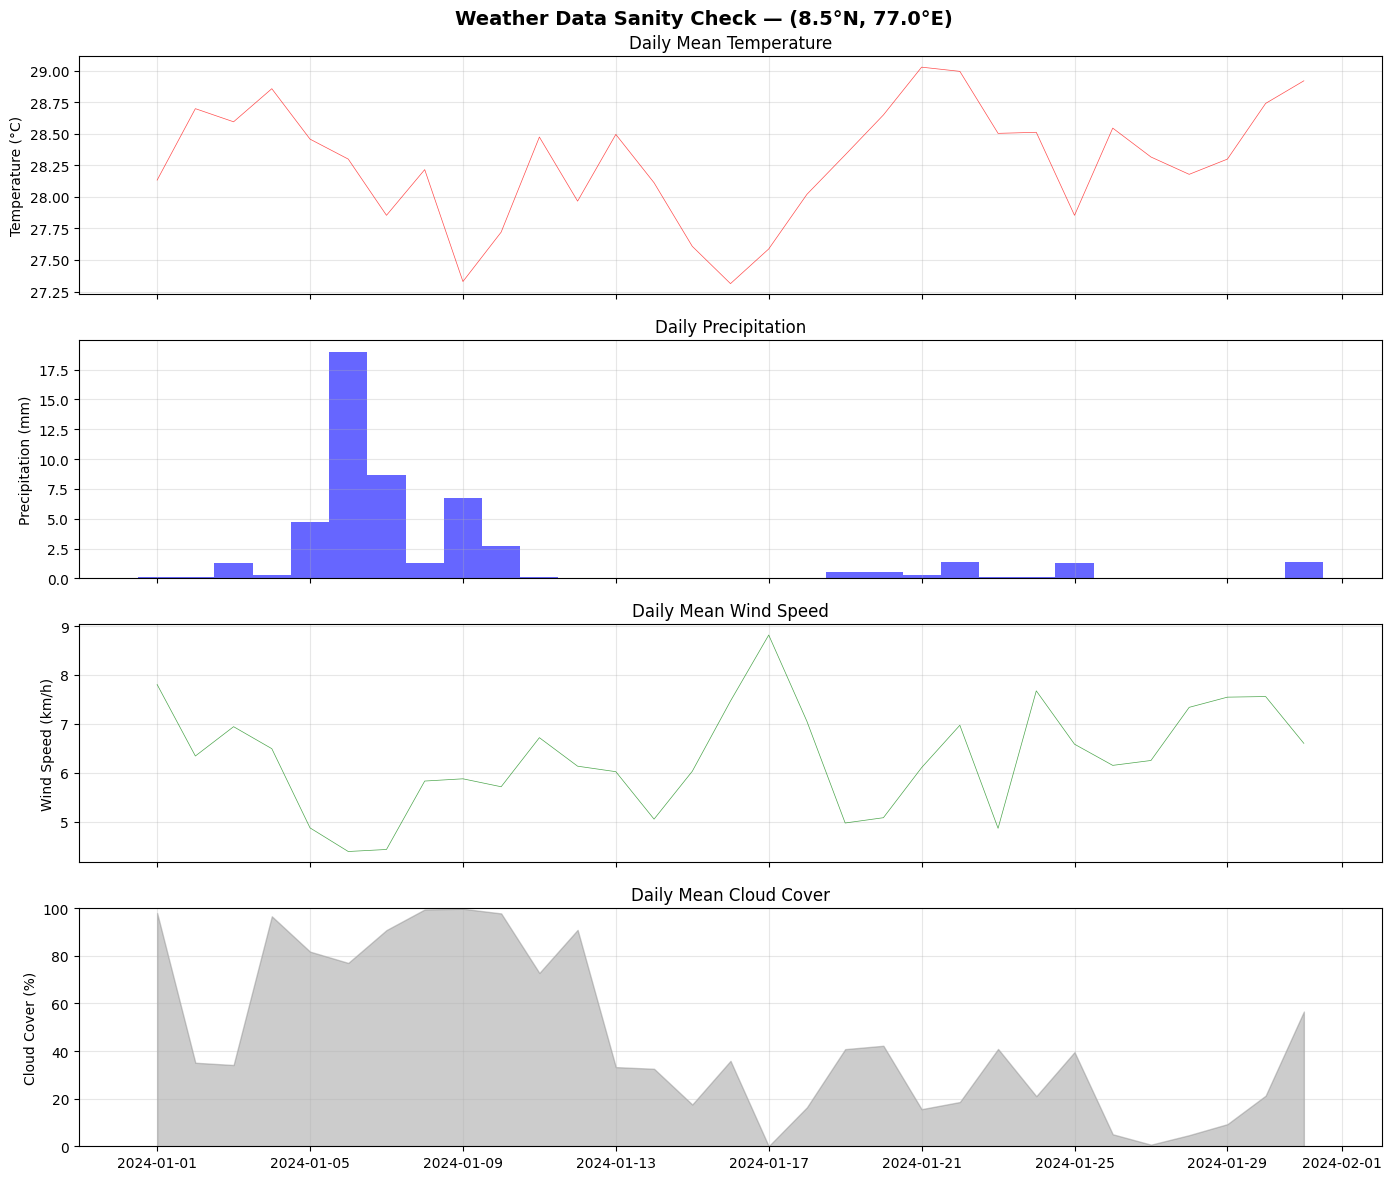

✅ Sanity check plot saved!


In [10]:
# ══════════════════════════════════════════════════════════════
#  STEP 9: QUICK SANITY CHECK — VISUALIZE 1 POINT
# ══════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

# Pick a central India point
sample_point = om_combined[
    (om_combined["latitude"] == 22.0) & 
    (om_combined["longitude"] == 78.0)
].sort_values("date")

if len(sample_point) == 0:
    # Fallback to first available point
    first_lat = om_combined["latitude"].iloc[0]
    first_lon = om_combined["longitude"].iloc[0]
    sample_point = om_combined[
        (om_combined["latitude"] == first_lat) & 
        (om_combined["longitude"] == first_lon)
    ].sort_values("date")

print(f"📍 Sample point: ({sample_point['latitude'].iloc[0]}, {sample_point['longitude'].iloc[0]})")
print(f"📅 Records: {len(sample_point)}")

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle(
    f"Weather Data Sanity Check — "
    f"({sample_point['latitude'].iloc[0]}°N, {sample_point['longitude'].iloc[0]}°E)",
    fontsize=14, fontweight="bold"
)

# Temperature
if "temperature_2m_mean" in sample_point.columns:
    axes[0].plot(sample_point["date"], sample_point["temperature_2m_mean"], 
                 color="red", linewidth=0.5, alpha=0.7)
    axes[0].set_ylabel("Temperature (°C)")
    axes[0].set_title("Daily Mean Temperature")
    axes[0].grid(True, alpha=0.3)

# Precipitation
if "precipitation_sum" in sample_point.columns:
    axes[1].bar(sample_point["date"], sample_point["precipitation_sum"], 
                color="blue", width=1, alpha=0.6)
    axes[1].set_ylabel("Precipitation (mm)")
    axes[1].set_title("Daily Precipitation")
    axes[1].grid(True, alpha=0.3)

# Wind
if "wind_speed_10m_mean" in sample_point.columns:
    axes[2].plot(sample_point["date"], sample_point["wind_speed_10m_mean"], 
                 color="green", linewidth=0.5, alpha=0.7)
    axes[2].set_ylabel("Wind Speed (km/h)")
    axes[2].set_title("Daily Mean Wind Speed")
    axes[2].grid(True, alpha=0.3)

# Cloud Cover
if "cloud_cover_mean" in sample_point.columns:
    axes[3].fill_between(sample_point["date"], sample_point["cloud_cover_mean"], 
                         color="gray", alpha=0.4)
    axes[3].set_ylabel("Cloud Cover (%)")
    axes[3].set_title("Daily Mean Cloud Cover")
    axes[3].set_ylim(0, 100)
    axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(FIGURES_DIR / "sanity_check_single_point.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Sanity check plot saved!")

In [11]:
# ══════════════════════════════════════════════════════════════
#  STEP 10: COLLECTION SUMMARY
# ══════════════════════════════════════════════════════════════

print("=" * 65)
print("  📋 DATA COLLECTION SUMMARY")
print("=" * 65)

om_files = list((RAW_DIR / "open_meteo").glob("open_meteo_PT_*.parquet"))
nasa_files = list((RAW_DIR / "nasa_power").glob("nasa_power_PT_*.parquet"))

om_size = sum(f.stat().st_size for f in om_files) / (1024**2)
nasa_size = sum(f.stat().st_size for f in nasa_files) / (1024**2)

print(f"""
   🌤️  Open-Meteo:
      Files:          {len(om_files)}
      Total size:     {om_size:.1f} MB
      Combined rows:  {len(om_combined):,}
      Columns:        {len(om_combined.columns)}
      
   🛰️  NASA POWER:
      Files:          {len(nasa_files)}
      Total size:     {nasa_size:.1f} MB
      Combined rows:  {len(nasa_combined):,}
      Columns:        {len(nasa_combined.columns)}
      
   📦 Total:
      Storage:        {om_size + nasa_size:.1f} MB
      
   📁 Saved to:
      {INTERIM_DIR / 'open_meteo_combined.parquet'}
      {INTERIM_DIR / 'nasa_power_combined.parquet'}
""")

# Check for failed points
om_failed = RAW_DIR / "open_meteo" / "failed_points.csv"
nasa_failed = RAW_DIR / "nasa_power" / "failed_points.csv"

if om_failed.exists():
    failed = pd.read_csv(om_failed)
    print(f"   ⚠️  Open-Meteo failed points: {len(failed)}")
    
if nasa_failed.exists():
    failed = pd.read_csv(nasa_failed)
    print(f"   ⚠️  NASA POWER failed points: {len(failed)}")

print("=" * 65)
print("  ✅ DATA COLLECTION COMPLETE — READY FOR PREPROCESSING!")
print("=" * 65)

  📋 DATA COLLECTION SUMMARY

   🌤️  Open-Meteo:
      Files:          0
      Total size:     0.0 MB
      Combined rows:  93
      Columns:        55

   🛰️  NASA POWER:
      Files:          0
      Total size:     0.0 MB
      Combined rows:  93
      Columns:        18

   📦 Total:
      Storage:        0.0 MB

   📁 Saved to:
      D:\Semester 6\Unsuperwised Learning\Project\weather-pattern-clustering\data\interim\open_meteo_combined.parquet
      D:\Semester 6\Unsuperwised Learning\Project\weather-pattern-clustering\data\interim\nasa_power_combined.parquet

   ⚠️  Open-Meteo failed points: 3
  ✅ DATA COLLECTION COMPLETE — READY FOR PREPROCESSING!
